In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util, exposure
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel, gaussian
from skimage.measure import label,  regionprops_table, regionprops,  moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation, remove_small_holes , erosion, closing, skeletonize, binary_closing, disk
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line
from skimage.filters import gaussian, threshold_otsu, threshold_sauvola, frangi, sato, threshold_yen, threshold_triangle
from skimage import util
from liffile import LifFile
import napari
import warnings
warnings.filterwarnings("ignore")

from skimage.graph import route_through_array




In [2]:
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6")
lif_files = list(folder.glob("*.lif"))
print(len(lif_files))


2


In [ ]:
# for lif_path in lif_files:
#     lif_name = "".join(os.path.basename(lif_path).lower().replace(".lif", "")).replace(".", "_")
#     print(lif_name)
#     with LifFile(lif_path) as lif:
#         number_of_lifs = len(lif.images)
#         print(number_of_lifs)
        
#         # for i in range(number_of_lifs):
#         #     output = segment_and_quantify(i,lif, lif_path, classifier_path)
#         #     all_outputs.append(output)
#         # totals = pd.concat(all_outputs)
#         # totals.to_csv("{}.csv".format(lif_name))
#         test = lif_files[0]

day5_exp6


In [3]:
lif_path = lif_files[1]
image_index = 0

dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[0]
    print("shape:", img.shape)


    # Often available:
    print("dims:", getattr(img, "dims", None))
    print("n_frames:", getattr(img, "n_frames", None))
    print("n_channels:", getattr(img, "n_channels", None))
    print("n_z", getattr(img, "n_z", None))
    print(f"Opened image {image_index}, {lif_files[image_index]}")
    img = img.asarray()


shape: (4, 3, 41, 512, 512)
dims: ('T', 'C', 'Z', 'Y', 'X')
n_frames: None
n_channels: None
n_z None
Opened image 0, Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6\Day5_Exp6.lif


In [4]:
dextran_t0 = img[0, dextran_channel, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)


dextran_t0 shape: (41, 512, 512)


In [88]:
def find_best_left_right_route(mask, ridge_weight=1.0, bg_penalty=10.0, edge_margin=8):
    H, W = mask.shape

    # Candidate endpoints in left/right margin bands
    left_band  = mask[:, :edge_margin]
    right_band = mask[:, W-edge_margin:]

    left_pts  = list(map(tuple, np.argwhere(left_band)))           # (y, x_in_band)
    left_pts  = [(y, x) for (y, x) in left_pts]                    # x already absolute in band
    right_pts = list(map(tuple, np.argwhere(right_band)))          # (y, x_in_band)
    right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]   # convert to absolute x

    # If we didn't get endpoints (mask slightly short), do a tiny dilation and retry
    if (len(left_pts) == 0) or (len(right_pts) == 0):
        print("extra dilation")
        m2 = binary_dilation(mask, footprint=disk(2))
        left_band  = m2[:, :edge_margin]
        right_band = m2[:, W-edge_margin:]
        left_pts  = list(map(tuple, np.argwhere(left_band)))
        right_pts = list(map(tuple, np.argwhere(right_band)))
        right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]
    else:
        m2 = mask

    # Cost: prefer skeleton, penalize background.
    # Use m2 (possibly dilated) to allow bridging tiny edge gaps without changing the skeleton itself.
    #cost = np.where(m2, ridge_weight, bg_penalty).astype(np.float32)
    step_cost = 100.0 # always pay this per pixel step (length penalty)
    off_penalty = step_cost * 5 # or 10
    cost = np.where(m2, step_cost, step_cost + off_penalty).astype(np.float32)

    # Cheap reduction of endpoints to avoid O(N^2) blow-up if bands are dense:
    # sample a subset if too many candidates
    max_candidates = 3
    if len(left_pts) > max_candidates:
        left_pts = [left_pts[i] for i in np.linspace(0, len(left_pts)-1, max_candidates).astype(int)]
    if len(right_pts) > max_candidates:
        right_pts = [right_pts[i] for i in np.linspace(0, len(right_pts)-1, max_candidates).astype(int)]

    best_score = np.inf
    best_path = None


    for s in left_pts:
        for t in right_pts:
            path, c = route_through_array(cost, s, t, fully_connected=True)
            path_len = len(path)


            off_count = sum(not m2[y, x] for (y, x) in path)
            score = path_len + 50 * off_count # increase 50→200 to force staying on m2


            if score < best_score:
                best_score = score
                best_path = path

    path_mask = np.zeros_like(mask, dtype=bool)
    if best_path is not None:
        for y, x in best_path:
            path_mask[y, x] = True
        return path_mask
    else:
        print("No path found (even with margin/dilation). Try increasing edge_margin or lowering bg_penalty.")
        return None
    
    

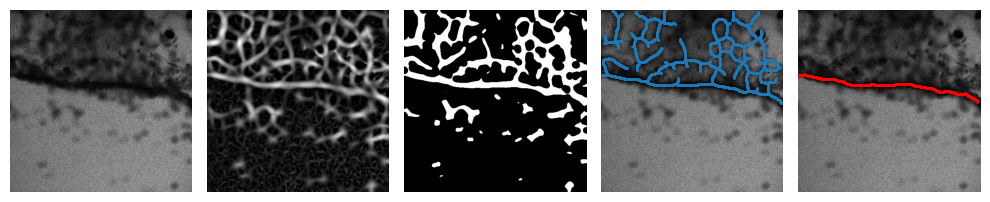

In [90]:
example_z = 28
slc = dextran_t0[example_z, :, :]  # renamed from `slice` to avoid shadowing built-in slice()

img_s = gaussian(slc, sigma=2)
img_s = exposure.equalize_adapthist(img_s, clip_limit=0.01)
ridge = sato(img_s, sigmas=np.linspace(2, 8, 10), black_ridges=True)
ridge = exposure.rescale_intensity(ridge)

thr = threshold_yen(ridge)
bw = ridge > thr

bw = binary_closing(bw, footprint=disk(9))

skel = skeletonize(bw)

lab = label(skel)
if lab.max() > 0:
    props = regionprops(lab)
    props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
    # keep top three (or fewer if <3 exist)
    labels_to_keep = [p.label for p in props_sorted[:3]]
    skel_main = np.isin(lab, labels_to_keep)
else:
    skel_main = skel

path_mask = find_best_left_right_route(skel_main)

    
# ----------------------------
# Visual check
# ----------------------------
fig, ax = plt.subplots(ncols=5, figsize=(10, 4))
ax[0].imshow(slc, cmap="gray")
ax[1].imshow(ridge, cmap="gray")
ax[2].imshow(bw, cmap="gray")
ax[3].imshow(slc, cmap="gray")
ys, xs = np.nonzero(skel_main)
ax[3].scatter(xs, ys, s=1)
ax[4].imshow(slc, cmap="gray")
y, x = np.nonzero(path_mask)
ax[4].scatter(x, y, s=1, c="red")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

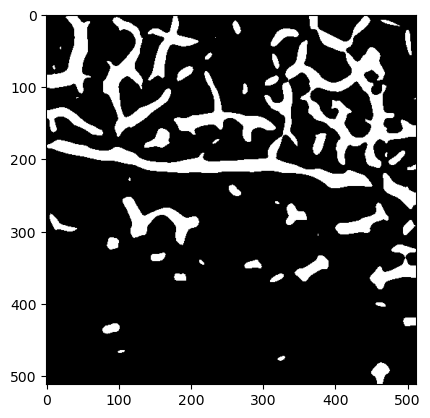

In [51]:
plt.imshow(bw, cmap="gray")

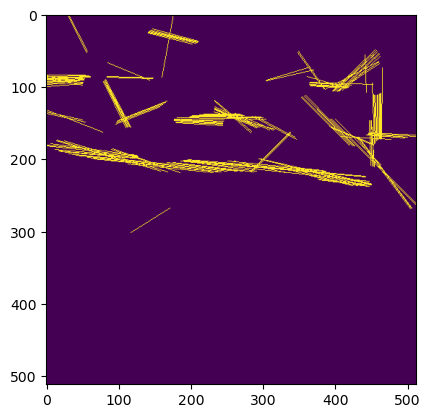

In [55]:

segs = probabilistic_hough_line(bw, line_length=50, line_gap=10, threshold=150)

recon = np.zeros_like(bw, dtype=bool)
for (x0, y0), (x1, y1) in segs:
    rr, cc = line(y0, x0, y1, x1)
    recon[rr, cc] = True
plt.imshow(recon)